In [1]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tqdm import tqdm


In [5]:
from pathlib import Path

class Config:
    # Training settings
    IMAGE_SIZE = 224
    BATCH_SIZE = 32
    NUM_EPOCHS = 10
    LEARNING_RATE = 1e-4
    VAL_SPLIT = 0.2
    NUM_CLASSES = 5

    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Resolve project root robustly from cwd
    _cwd = Path.cwd().resolve()
    _candidates = [
        _cwd,
        _cwd / 'dlproj' / 'diabetic-retinopathy-grading',
    ]
    _project_root = None
    for p in _candidates + list(_cwd.parents):
        direct = p
        nested = p / 'dlproj' / 'diabetic-retinopathy-grading'
        if (direct / 'data' / 'raw' / 'train.csv').exists():
            _project_root = direct
            break
        if (nested / 'data' / 'raw' / 'train.csv').exists():
            _project_root = nested
            break
    if _project_root is None:
        raise FileNotFoundError('Could not locate project root containing data/raw/train.csv')

    PROJECT_ROOT = _project_root
    DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
    TRAIN_CSV = DATA_DIR / 'train.csv'
    TRAIN_IMAGES = DATA_DIR / 'train_images'
    RESULTS_DIR = PROJECT_ROOT / 'results' / 'baseline'

    os.makedirs(RESULTS_DIR, exist_ok=True)

config = Config()
print(f'Using device: {config.DEVICE}')
print(f'Project root: {config.PROJECT_ROOT}')

Using device: cuda
Project root: D:\lums\ai600\assignments\dlproj\diabetic-retinopathy-grading


In [6]:

class DRDataset(Dataset):
    """Dataset for diabetic retinopathy images"""
    
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_id = self.df.loc[idx, 'id_code']
        label = self.df.loc[idx, 'diagnosis']
        
        img_path = os.path.join(self.image_dir, f'{img_id}.png')
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label


In [7]:

print("\nLoading data...")

# Load CSV
df = pd.read_csv(config.TRAIN_CSV)
print(f"Total images: {len(df)}")

# Show class distribution
print("\nClass distribution:")
for grade, count in df['diagnosis'].value_counts().sort_index().items():
    percentage = count / len(df) * 100
    print(f"  Grade {grade}: {count:4d} ({percentage:5.2f}%)")

# Train/val split
train_df, val_df = train_test_split(
    df,
    test_size=config.VAL_SPLIT,
    stratify=df['diagnosis'],
    random_state=42
)

print(f"\nSplit:")
print(f"  Train: {len(train_df)} images")
print(f"  Val:   {len(val_df)} images")

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = DRDataset(train_df, config.TRAIN_IMAGES, train_transform)
val_dataset = DRDataset(val_df, config.TRAIN_IMAGES, val_transform)

# Create dataloaders
# Note: num_workers=0 for Windows compatibility (use 4 on Linux/Mac for speed)
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")



Loading data...
Total images: 3662

Class distribution:
  Grade 0: 1805 (49.29%)
  Grade 1:  370 (10.10%)
  Grade 2:  999 (27.28%)
  Grade 3:  193 ( 5.27%)
  Grade 4:  295 ( 8.06%)

Split:
  Train: 2929 images
  Val:   733 images

DataLoaders created:
  Train batches: 92
  Val batches:   23


In [8]:
print("\nCreating model...")

model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, config.NUM_CLASSES)
model = model.to(config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model: ResNet18")
print(f"Parameters: {total_params:,}")



Creating model...


d:\lums\ai600\assignments\ai600_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\lums\ai600\assignments\ai600_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model: ResNet18
Parameters: 11,179,077


In [9]:
criterion = nn.CrossEntropyLoss()  # Standard cross-entropy (no weights)
optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

print(f"\nLoss: Cross-Entropy (unweighted)")
print(f"Optimizer: Adam (lr={config.LEARNING_RATE})")

# ============================================================================
# METRICS
# ============================================================================

def calculate_metrics(y_true, y_pred):
    """Calculate QWK, accuracy, and confusion matrix"""
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    accuracy = (y_true == y_pred).mean()
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4])
    return {'qwk': qwk, 'accuracy': accuracy, 'confusion_matrix': cm}



Loss: Cross-Entropy (unweighted)
Optimizer: Adam (lr=0.0001)


In [10]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(train_loader, desc='Training')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return running_loss / len(train_loader)


In [11]:
def validate(model, val_loader, criterion, device):
    """Validate model"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc='Validation')
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            _, preds = torch.max(outputs, 1)
            
            running_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = running_loss / len(val_loader)
    metrics = calculate_metrics(np.array(all_labels), np.array(all_preds))
    
    return avg_loss, metrics, all_preds, all_labels


In [12]:

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

history = {
    'train_loss': [],
    'val_loss': [],
    'val_qwk': [],
    'val_accuracy': []
}

best_qwk = 0.0

for epoch in range(config.NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{config.NUM_EPOCHS}")
    print("-" * 60)
    
    # Train
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, config.DEVICE)
    
    # Validate
    val_loss, metrics, preds, labels = validate(model, val_loader, criterion, config.DEVICE)
    
    # Print results
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val QWK:    {metrics['qwk']:.4f}")
    print(f"Val Acc:    {metrics['accuracy']:.4f}")
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_qwk'].append(metrics['qwk'])
    history['val_accuracy'].append(metrics['accuracy'])
    
    # Save best model
    if metrics['qwk'] > best_qwk:
        best_qwk = metrics['qwk']
        torch.save(model.state_dict(), os.path.join(config.RESULTS_DIR, 'best_model.pth'))
        print(f"✓ New best model saved (QWK: {best_qwk:.4f})")

print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)
print(f"Best Validation QWK: {best_qwk:.4f}")



STARTING TRAINING

Epoch 1/10
------------------------------------------------------------


Validation: 100%|██████████| 23/23 [00:59<00:00,  2.57s/it]


Train Loss: 0.6447
Val Loss:   0.5387
Val QWK:    0.8544
Val Acc:    0.8063
✓ New best model saved (QWK: 0.8544)

Epoch 2/10
------------------------------------------------------------


Validation: 100%|██████████| 23/23 [00:56<00:00,  2.47s/it]


Train Loss: 0.3325
Val Loss:   0.4943
Val QWK:    0.8601
Val Acc:    0.8172
✓ New best model saved (QWK: 0.8601)

Epoch 3/10
------------------------------------------------------------


...

Train Loss: 0.0317
Val Loss:   0.7119
Val QWK:    0.8805
Val Acc:    0.8349
✓ New best model saved (QWK: 0.8805)

Epoch 9/10
------------------------------------------------------------


Validation: 100%|██████████| 23/23 [00:54<00:00,  2.35s/it]


Train Loss: 0.0272
Val Loss:   0.7281
Val QWK:    0.8759
Val Acc:    0.8267

Epoch 10/10
------------------------------------------------------------


Validation: 100%|██████████| 23/23 [00:52<00:00,  2.29s/it]


Train Loss: 0.0225
Val Loss:   0.7346
Val QWK:    0.8819
Val Acc:    0.8349
✓ New best model saved (QWK: 0.8819)

TRAINING COMPLETE
Best Validation QWK: 0.8819


In [13]:

print("\n" + "="*60)
print("FINAL EVALUATION")
print("="*60)

# Load best model
model.load_state_dict(torch.load(os.path.join(config.RESULTS_DIR, 'best_model.pth')))

# Evaluate
val_loss, metrics, preds, labels = validate(model, val_loader, criterion, config.DEVICE)

print(f"\nFinal Metrics:")
print(f"  QWK:      {metrics['qwk']:.4f}")
print(f"  Accuracy: {metrics['accuracy']:.4f}")

# Classification report
print("\nPer-Class Performance:")
print("-" * 60)
report = classification_report(
    labels, preds,
    target_names=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'],
    digits=4
)
print(report)

# Save report
with open(os.path.join(config.RESULTS_DIR, 'classification_report.txt'), 'w') as f:
    f.write(report)



FINAL EVALUATION


C:\Users\azama\AppData\Local\Temp\ipykernel_6440\256094641.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(config.RESULTS_D


Final Metrics:
  QWK:      0.8819
  Accuracy: 0.8349

Per-Class Performance:
------------------------------------------------------------
              precision    recall  f1-score   support

     Grade 0     0.9464    0.9778    0.9619       361
     Grade 1     0.6607    0.5000    0.5692        74
     Grade 2     0.7644    0.8600    0.8094       200
     Grade 3     0.6818    0.3846    0.4918        39
     Grade 4     0.6140    0.5932    0.6034        59

    accuracy                         0.8349       733
   macro avg     0.7335    0.6631    0.6871       733
weighted avg     0.8271    0.8349    0.8268       733




Generating visualizations...
✓ Training curves saved


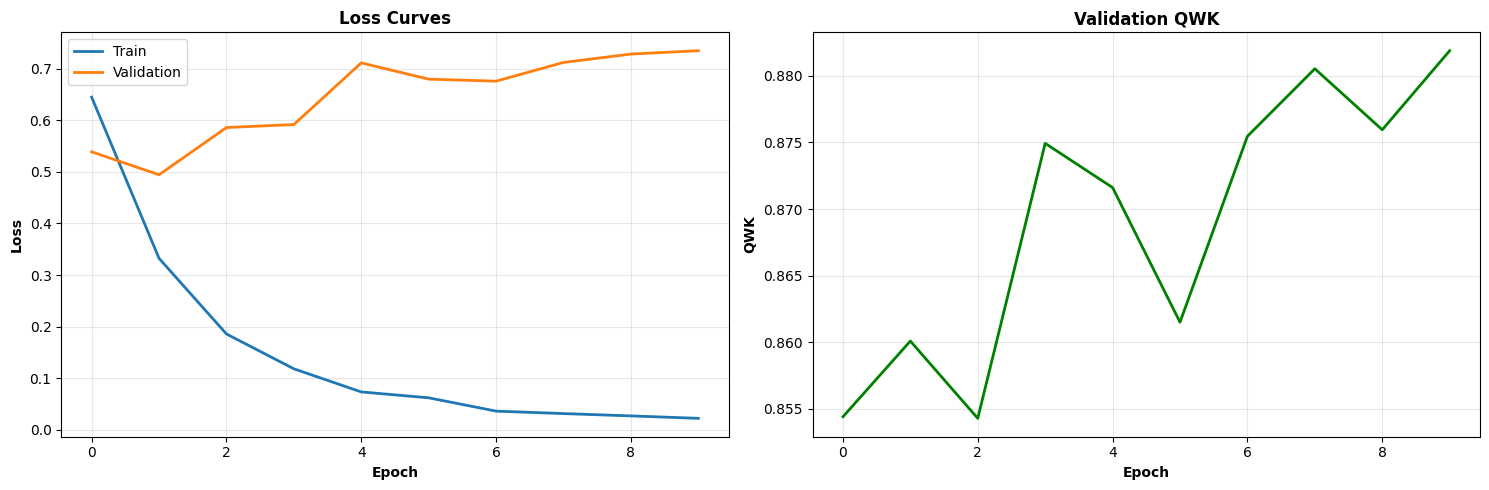

In [14]:
print("\nGenerating visualizations...")

# 1. Training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Loss', fontweight='bold')
axes[0].set_title('Loss Curves', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_qwk'], linewidth=2, color='green')
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('QWK', fontweight='bold')
axes[1].set_title('Validation QWK', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'training_curves.png'), dpi=150)
print("✓ Training curves saved")


✓ Confusion matrix saved


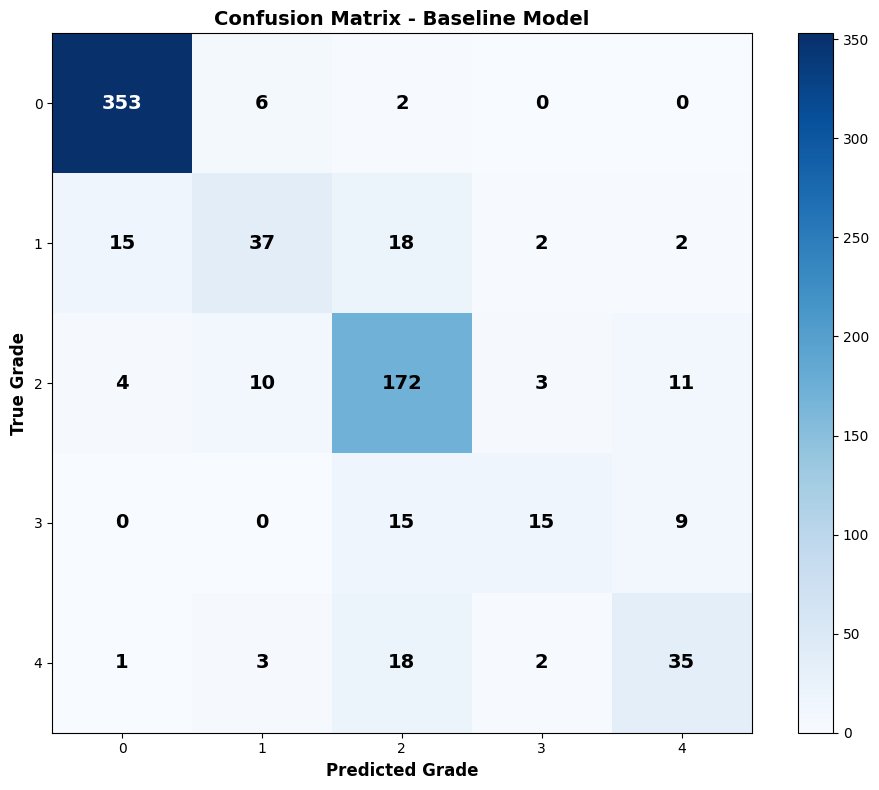

In [15]:

# 2. Confusion matrix
cm = metrics['confusion_matrix']

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()

for i in range(5):
    for j in range(5):
        color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        plt.text(j, i, cm[i, j], ha='center', va='center',
                color=color, fontsize=14, fontweight='bold')

plt.xlabel('Predicted Grade', fontweight='bold', fontsize=12)
plt.ylabel('True Grade', fontweight='bold', fontsize=12)
plt.title('Confusion Matrix - Baseline Model', fontweight='bold', fontsize=14)
plt.xticks([0, 1, 2, 3, 4])
plt.yticks([0, 1, 2, 3, 4])
plt.tight_layout()
plt.savefig(os.path.join(config.RESULTS_DIR, 'confusion_matrix.png'), dpi=150)
print("✓ Confusion matrix saved")


In [16]:

print("\n" + "="*60)
print("BASELINE RESULTS SUMMARY")
print("="*60)
print(f"Final Validation QWK: {metrics['qwk']:.4f}")
print(f"Final Validation Accuracy: {metrics['accuracy']:.4f}")
print(f"\nResults saved to: {config.RESULTS_DIR}")
print("\nFiles created:")
print("  - best_model.pth")
print("  - training_curves.png")
print("  - confusion_matrix.png")
print("  - classification_report.txt")
print("="*60)

print("\n✅ BASELINE COMPLETE!")
print("\nNext steps:")
print("1. Review the confusion matrix - which grades are confused?")
print("2. Check per-class F1 scores - which classes perform poorly?")
print("3. We'll systematically improve these problems!")



BASELINE RESULTS SUMMARY
Final Validation QWK: 0.8819
Final Validation Accuracy: 0.8349

Results saved to: D:\lums\ai600\assignments\dlproj\diabetic-retinopathy-grading\results\baseline

Files created:
  - best_model.pth
  - training_curves.png
  - confusion_matrix.png
  - classification_report.txt

✅ BASELINE COMPLETE!

Next steps:
1. Review the confusion matrix - which grades are confused?
2. Check per-class F1 scores - which classes perform poorly?
3. We'll systematically improve these problems!
